# Python Data Analytics Class Exercise
## Czech Bank Dataset — Data Cleaning, Consolidation & Feature Engineering

**Prepared by:** Christine Nabisswa

### Exercise Description

This document presents my completed class exercise using the Czech Bank dataset. The exercise documents the data cleaning, consolidation, and feature engineering process, including multi-table joins across account, district, and transaction records, iterative and mean imputation for missing values, outlier verification, and categorical binning of account age and transaction amounts to support downstream analytical review.

### 1. Import the libraries

In [ ]:
import pandas as pd

2. Import the data from three csv files as DataFrames account, district, trans

In [ ]:
account=pd.read_csv('account.csv')
district=pd.read_csv('district.csv')

In [ ]:
trans=pd.read_csv('trans.csv')

/tmp/ipykernel_10028/691700751.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  trans=pd.read_csv('trans.csv')


In [ ]:
# To correct the dtype warning as shown below

In [ ]:
trans = pd.read_csv('trans.csv', dtype={'partner_bank': 'string'})

### 3. Look at the info summary, head of each DataFrame

In [ ]:
account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   account_id         4500 non-null   int64 
 1   district_id        4500 non-null   int64 
 2   frequency          4500 non-null   object
 3   account_open_date  4500 non-null   object
 4   client_id          4500 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 175.9+ KB


In [ ]:
account.head()

,account_id,district_id,frequency,account_open_date,client_id
0,576,55,MONTHLY STATEMENTS,1993-01-01,692
1,3818,74,MONTHLY STATEMENTS,1993-01-01,4601
2,704,55,MONTHLY STATEMENTS,1993-01-01,844
3,2378,16,MONTHLY STATEMENTS,1993-01-01,2873
4,2632,24,MONTHLY STATEMENTS,1993-01-02,3177


In [ ]:
district.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   district_id           76 non-null     int64  
 1   district_name         76 non-null     object 
 2   region                76 non-null     object 
 3   population            76 non-null     int64  
 4   average_salary        66 non-null     float64
 5   unemployment_rate     66 non-null     float64
 6   num_committed_crimes  67 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 4.3+ KB


In [ ]:
district.head()

,district_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,1,Hl.m. Praha,Prague,1204953,12541.0,0.43,99107.0
1,2,Benesov,central Bohemia,88884,NaN,NaN,2674.0
2,3,Beroun,central Bohemia,75232,8980.0,2.21,2813.0
3,4,Kladno,central Bohemia,149893,9753.0,5.05,NaN
4,5,Kolin,central Bohemia,95616,9307.0,4.43,NaN


In [ ]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   trans_id         1056320 non-null  int64  
 1   account_id       1056320 non-null  int64  
 2   date             1056320 non-null  object 
 3   type             1056320 non-null  object 
 4   operation_type   873206 non-null   object 
 5   amount           1056320 non-null  float64
 6   balance          1056320 non-null  float64
 7   description      574439 non-null   object 
 8   partner_bank     273508 non-null   string 
 9   partner_account  295389 non-null   float64
dtypes: float64(3), int64(2), object(4), string(1)
memory usage: 80.6+ MB


In [ ]:
trans.head()

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,NaN,<NA>,NaN
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,NaN,<NA>,NaN
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,NaN,<NA>,NaN
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,NaN,<NA>,NaN
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,NaN,<NA>,NaN


A few key things to notice:
- We must fix the data types for some columns
- There is missing data
- These datasets have connections among them:
  - `account` and `trans` have common column named `account_id`
  - `account` and `district` have common column named `district_id`

### 4. Check for the unique values and their counts in each column for the three DataFrames

In [ ]:
account.nunique()

,0
account_id,4500
district_id,77
frequency,3
account_open_date,1535
client_id,4500


In [ ]:
district.nunique()

,0
district_id,76
district_name,76
region,8
population,76
average_salary,65
unemployment_rate,63
num_committed_crimes,66


In [ ]:
trans.nunique()

,0
trans_id,1056320
account_id,4500
date,2191
type,2
operation_type,5
amount,40400
balance,542739
description,8
partner_bank,13
partner_account,7665


All columns have at least 2 unique values

### 5. Check for duplicates in the three DataFrames

In [ ]:
account.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4495,False
4496,False
4497,False
4498,False


In [ ]:
account[account.duplicated()]

,account_id,district_id,frequency,account_open_date,client_id


In [ ]:
# boolean shows False
# no duplicates for account

In [ ]:
district.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
71,False
72,False
73,False
74,False


In [ ]:
district[district.duplicated()]

,district_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes


In [ ]:
# boolean shows False
# no duplicates for district

In [ ]:
trans.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1056315,False
1056316,False
1056317,False
1056318,False


In [ ]:
trans[trans.duplicated()]

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account


In [ ]:
# boolean shows False
# no duplicates for trans

No duplicated rows in the DataFrames

### 6. Convert column `account_open_date` in `account` and column `date` in `trans` into datetime dtypes

In [ ]:
account['account_open_date']=pd.to_datetime(account['account_open_date'])

In [ ]:
trans['date']=pd.to_datetime(trans['date'])

In [ ]:
# checking whether they have been converted from object to datetime.Yes they have

In [ ]:
account.dtypes

,0
account_id,int64
district_id,int64
frequency,object
account_open_date,datetime64[ns]
client_id,int64


In [ ]:
trans.dtypes

,0
trans_id,int64
account_id,int64
date,datetime64[ns]
type,object
operation_type,object
amount,float64
balance,float64
description,object
partner_bank,string[python]
partner_account,float64


### 7. Convert the columns `region` and `district_name` in `district` to all uppercase

In [ ]:
district['region'] = district['region'].str.upper()

In [ ]:
district['district_name'] = district['district_name'].str.upper()

In [ ]:
district.head()

,district_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,1,HL.M. PRAHA,PRAGUE,1204953,12541.0,0.43,99107.0
1,2,BENESOV,CENTRAL BOHEMIA,88884,NaN,NaN,2674.0
2,3,BEROUN,CENTRAL BOHEMIA,75232,8980.0,2.21,2813.0
3,4,KLADNO,CENTRAL BOHEMIA,149893,9753.0,5.05,NaN
4,5,KOLIN,CENTRAL BOHEMIA,95616,9307.0,4.43,NaN


### 8. Check for missing data by columns in `account` using the `isna` method

In [ ]:
account.isna()

,account_id,district_id,frequency,account_open_date,client_id
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
4495,False,False,False,False,False
4496,False,False,False,False,False
4497,False,False,False,False,False
4498,False,False,False,False,False


In [ ]:
account.isna().sum()

,0
account_id,0
district_id,0
frequency,0
account_open_date,0
client_id,0


No missing data in this dataset

### 9. Check for missing data by columns in `district` using the `isna` method

In [ ]:
district.isna()

,district_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,False,False,False,False,False,False,False
1,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True
4,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...
71,False,False,False,False,True,False,False
72,False,False,False,False,False,False,False
73,False,False,False,False,False,False,False
74,False,False,False,False,False,False,False


In [ ]:
district.isna().sum()

,0
district_id,0
district_name,0
region,0
population,0
average_salary,10
unemployment_rate,10
num_committed_crimes,9


`district` has numeric features that could have relationships with each other. Let's use iterative imputation on them.

#### Use `IterativeImputer` in `sklearn` to impute based on columns `population`, `average_salary`, `unemployment_rate`, `num_committed_crimes`

##### Import libraries

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

##### Build a list of columns that will be used for imputation, which are `population`, `average_salary`, `unemployment_rate`, `num_committed_crimes`
These are the columns that might be related to each other

In [ ]:
cols_to_impute = ['population', 'average_salary', 'unemployment_rate', 'num_committed_crimes']

##### Create `IterativeImputer` object and set its `min_value` and `max_value` parameters to be the minumum and maximum of corresponding columns

In [ ]:
iter_imp = IterativeImputer(min_value=district[cols_to_impute].min(), max_value=district[cols_to_impute].max())

##### Apply the imputer to fit and transform the columns to an imputed NumPy array

In [ ]:
imputed_cols = iter_imp.fit_transform(district[cols_to_impute])

##### Assign the imputed array back to the original DataFrame's columns

In [ ]:
district[cols_to_impute] = imputed_cols

##### Double check that the columns are imputed

In [ ]:
district.isna().sum()

,0
district_id,0
district_name,0
region,0
population,0
average_salary,0
unemployment_rate,0
num_committed_crimes,0


### 10. Check for missing data by columns in `trans` using the `isna` method

In [ ]:
trans.isna()

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account
0,False,False,False,False,False,False,False,True,True,True
1,False,False,False,False,False,False,False,True,True,True
2,False,False,False,False,False,False,False,True,True,True
3,False,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...
1056315,False,False,False,False,True,False,False,False,True,True
1056316,False,False,False,False,True,False,False,False,True,True
1056317,False,False,False,False,True,False,False,False,True,True
1056318,False,False,False,False,True,False,False,False,True,True


In [ ]:
trans.isna().sum()

,0
trans_id,0
account_id,0
date,0
type,0
operation_type,183114
amount,0
balance,0
description,481881
partner_bank,782812
partner_account,760931


#### Divide the columns into numeric columns and categorical columns, then use the `fillna` method to fill numeric columns with -999, fill categorical columns with 'UNKNOWN'

In [ ]:
numeric_cols=trans.select_dtypes(include='number').columns
cat_cols=trans.select_dtypes(exclude='number').columns

In [ ]:
### Use of fillna() method to impute missing data

In [ ]:
trans[numeric_cols] = trans[numeric_cols].fillna(-999)

In [ ]:
trans[cat_cols] = trans[cat_cols].fillna('UNKNOWN')

In [ ]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   trans_id         1056320 non-null  int64         
 1   account_id       1056320 non-null  int64         
 2   date             1056320 non-null  datetime64[ns]
 3   type             1056320 non-null  object        
 4   operation_type   1056320 non-null  object        
 5   amount           1056320 non-null  float64       
 6   balance          1056320 non-null  float64       
 7   description      1056320 non-null  object        
 8   partner_bank     1056320 non-null  string        
 9   partner_account  1056320 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3), string(1)
memory usage: 80.6+ MB


### 11. Check for outliers in `district` using the `describe` method, then look at the histograms of the suspicious columns

In [ ]:
district.describe().T

,count,mean,std,min,25%,50%,75%,max
district_id,76.0,38.500000,22.083176,1.00,19.750000,38.500000,57.25000,76.0
population,76.0,133692.000000,137812.665884,42821.00,84725.000000,108391.000000,138277.00000,1204953.0
average_salary,76.0,8983.707247,740.959314,8110.00,8533.750000,8792.984750,9280.75000,12541.0
unemployment_rate,76.0,3.864003,1.721597,0.43,2.650000,3.761936,4.57000,9.4
num_committed_crimes,76.0,5054.492038,11392.279917,888.00,1918.454646,2864.000000,4562.41324,99107.0


array([[<Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'average_salary'}>],
       [<Axes: title={'center': 'unemployment_rate'}>,
        <Axes: title={'center': 'num_committed_crimes'}>]], dtype=object)

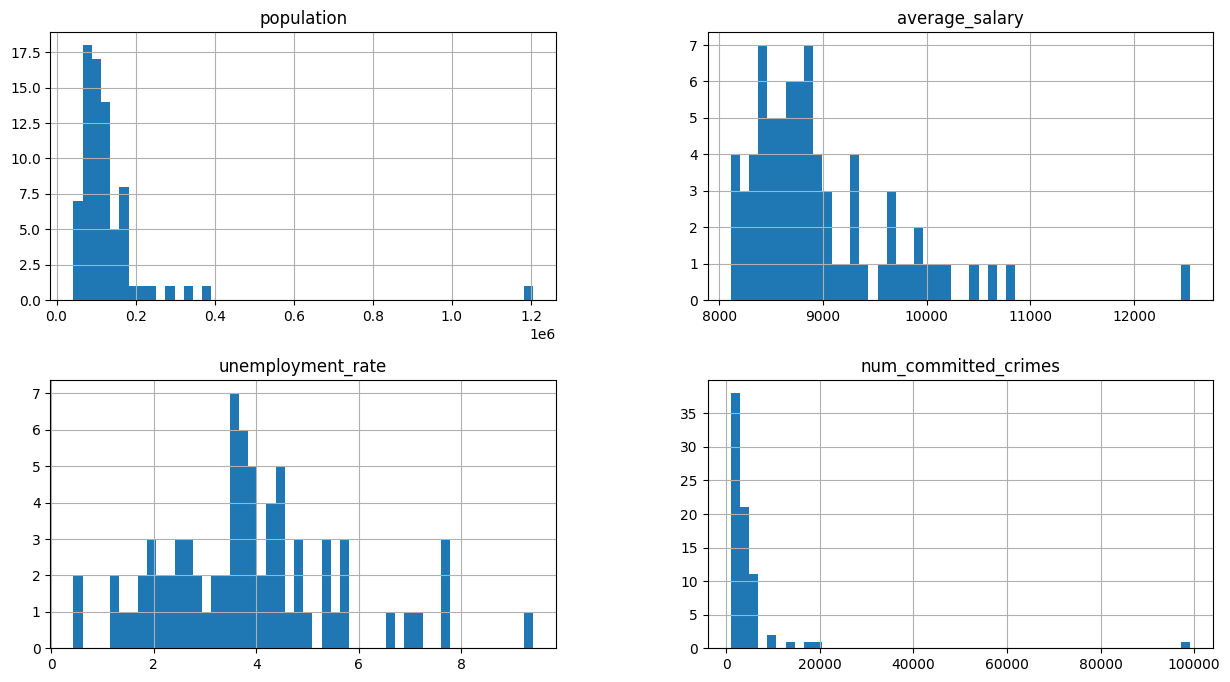

In [ ]:
district[['population', 'average_salary', 'unemployment_rate', 'num_committed_crimes']].hist(bins=50, figsize=(15, 8))

#### Explore the outliers in the dataset

In [ ]:
district.nlargest(1, columns='population')

,district_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,1,HL.M. PRAHA,PRAGUE,1204953.0,12541.0,0.43,99107.0


The most obvious outlier seems to come from the same district. It is a district with large `population`, higher `average_salary`, as well as higher `num_committed_crimes`. Since we don't have enough reasons to remove it, we'll leave it.

### 12. Check for outliers in `trans` using the `describe` method, then look at the histograms of the suspicious columns

In [ ]:
trans.describe().T

,count,mean,min,25%,50%,75%,max,std
trans_id,1056320.0,1335310.70433,1.0,430262.75,858506.5,2060979.25,3682987.0,1227486.508382
account_id,1056320.0,2936.86729,1.0,1204.0,2434.0,3660.0,11382.0,2477.345127
date,1056320,1997-01-04 07:29:27.037261952,1993-01-01 00:00:00,1996-01-16 00:00:00,1997-04-10 00:00:00,1998-02-28 00:00:00,1998-12-31 00:00:00,NaN
amount,1056320.0,5924.145676,0.0,135.9,2100.0,6800.0,87400.0,9522.735373
balance,1056320.0,38518.330803,-41125.7,22402.5,33143.4,49603.625,209637.0,22117.868013
partner_account,1056320.0,12770682.211042,-999.0,-999.0,-999.0,3410566.0,99994199.0,26136576.177962


array([[<Axes: title={'center': 'amount'}>,
        <Axes: title={'center': 'balance'}>]], dtype=object)

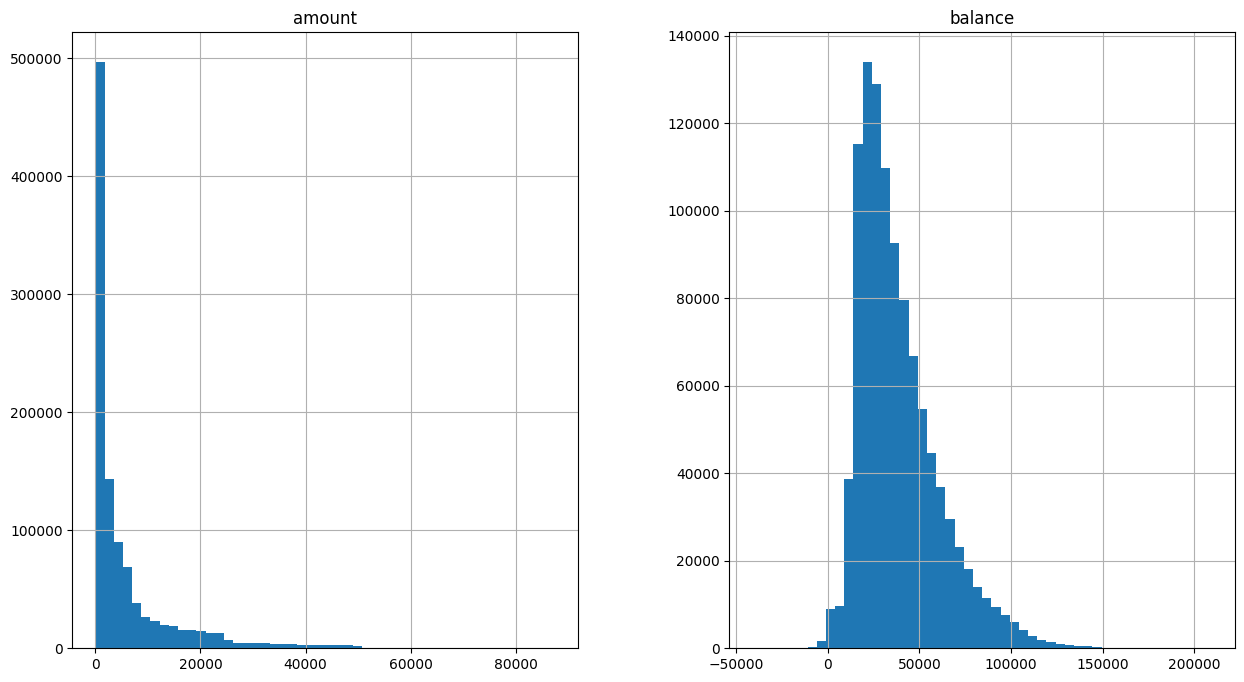

In [ ]:
trans[['amount', 'balance']].hist(bins=50, figsize=(15, 8)) # based on mean

#### Explore the outliers in the dataset

In [ ]:
trans[trans['amount'] > 60000]

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account
422,1313408,4484,1993-02-23,DEBIT,WITHDRAWAL IN CASH,62100.0,41183.0,UNKNOWN,UNKNOWN,-999.0
1287,1450519,4937,1993-04-04,DEBIT,WITHDRAWAL IN CASH,60500.0,74071.2,UNKNOWN,UNKNOWN,-999.0
3565,303136,1032,1993-06-05,CREDIT,COLLECTION FROM ANOTHER BANK,74648.0,112843.8,UNKNOWN,GH,43027007.0
3635,655858,2242,1993-06-06,CREDIT,COLLECTION FROM ANOTHER BANK,65240.0,126832.2,UNKNOWN,CD,7862908.0
3783,894506,3050,1993-06-08,CREDIT,COLLECTION FROM ANOTHER BANK,62168.0,73568.0,UNKNOWN,GH,69871258.0
...,...,...,...,...,...,...,...,...,...,...
1049226,602639,2051,1998-12-21,DEBIT,WITHDRAWAL IN CASH,62000.0,71187.7,UNKNOWN,UNKNOWN,-999.0
1049504,302367,1029,1998-12-22,DEBIT,WITHDRAWAL IN CASH,63800.0,57501.1,UNKNOWN,UNKNOWN,-999.0
1049791,335369,1139,1998-12-23,DEBIT,WITHDRAWAL IN CASH,62600.0,90537.9,UNKNOWN,UNKNOWN,-999.0
1050834,414144,1407,1998-12-26,DEBIT,WITHDRAWAL IN CASH,62700.0,73836.1,UNKNOWN,UNKNOWN,-999.0


In [ ]:
trans.loc[trans['amount'] > 60000, 'operation_type'].value_counts()

,count
operation_type,
WITHDRAWAL IN CASH,837
COLLECTION FROM ANOTHER BANK,738


In [ ]:
trans[trans['balance'] > 150000]

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account
2832,695256,2378,1993-05-19,CREDIT,CREDIT IN CASH,43637.0,151483.0,UNKNOWN,UNKNOWN,-999.0
2872,576769,1965,1993-05-21,CREDIT,CREDIT IN CASH,33711.0,156483.5,UNKNOWN,UNKNOWN,-999.0
3037,1100776,3760,1993-05-29,CREDIT,CREDIT IN CASH,38405.0,169292.1,UNKNOWN,UNKNOWN,-999.0
7797,637133,2176,1993-08-02,CREDIT,CREDIT IN CASH,47024.0,193909.9,UNKNOWN,UNKNOWN,-999.0
16229,615555,2099,1993-10-18,CREDIT,CREDIT IN CASH,36684.0,184168.4,UNKNOWN,UNKNOWN,-999.0
...,...,...,...,...,...,...,...,...,...,...
1050134,3317727,11021,1998-12-24,CREDIT,CREDIT IN CASH,42890.0,160348.0,UNKNOWN,UNKNOWN,-999.0
1050758,2675921,8856,1998-12-26,CREDIT,CREDIT IN CASH,46170.0,192662.5,UNKNOWN,UNKNOWN,-999.0
1050912,3215715,10670,1998-12-27,CREDIT,CREDIT IN CASH,44890.0,173945.9,UNKNOWN,UNKNOWN,-999.0
1051009,157025,525,1998-12-27,CREDIT,CREDIT IN CASH,46726.0,158444.3,UNKNOWN,UNKNOWN,-999.0


In [ ]:
trans.loc[trans['balance'] > 150000, 'operation_type'].value_counts()

,count
operation_type,
CREDIT IN CASH,312
WITHDRAWAL IN CASH,18
COLLECTION FROM ANOTHER BANK,14
UNKNOWN,4
REMITTANCE TO ANOTHER BANK,4
CREDIT CARD WITHDRAWAL,2


They look like real data. So we'll just keep them.

The DataFrame `account` doesn't have any columns that could have outliers, so we are not exploring it.

### 13. Merge (left join) `account` and `district` into a new DataFrame called `account_district` using their common columns

In [ ]:
account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   account_id         4500 non-null   int64         
 1   district_id        4500 non-null   int64         
 2   frequency          4500 non-null   object        
 3   account_open_date  4500 non-null   datetime64[ns]
 4   client_id          4500 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 175.9+ KB


In [ ]:
district.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   district_id           76 non-null     int64  
 1   district_name         76 non-null     object 
 2   region                76 non-null     object 
 3   population            76 non-null     float64
 4   average_salary        76 non-null     float64
 5   unemployment_rate     76 non-null     float64
 6   num_committed_crimes  76 non-null     float64
dtypes: float64(4), int64(1), object(2)
memory usage: 4.3+ KB


In [ ]:
# both share district id column

In [ ]:
account_district = pd.merge(account, district, on='district_id', how='left')

### 14. Check the information summary of `account_district`, any missing data?

In [ ]:
account_district.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   account_id            4500 non-null   int64         
 1   district_id           4500 non-null   int64         
 2   frequency             4500 non-null   object        
 3   account_open_date     4500 non-null   datetime64[ns]
 4   client_id             4500 non-null   int64         
 5   district_name         4460 non-null   object        
 6   region                4460 non-null   object        
 7   population            4460 non-null   float64       
 8   average_salary        4460 non-null   float64       
 9   unemployment_rate     4460 non-null   float64       
 10  num_committed_crimes  4460 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 386.8+ KB


After doing the left join, there is more missing data. That means there were some `district_id`s in `account`, but not in `district`. It is common that after combining the datasets we need to clean the data more

#### Look at the rows with missing data in `account_district`

In [ ]:
msk = account_district.isna().sum(axis=1) > 0
account_district[msk].head(10)

,account_id,district_id,frequency,account_open_date,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
5,1972,77,MONTHLY STATEMENTS,1993-01-02,2397,NaN,NaN,NaN,NaN,NaN,NaN
77,1000,77,MONTHLY STATEMENTS,1993-01-25,1204,NaN,NaN,NaN,NaN,NaN,NaN
308,299,77,MONTHLY STATEMENTS,1993-04-05,364,NaN,NaN,NaN,NaN,NaN,NaN
322,8321,77,MONTHLY STATEMENTS,1993-04-12,10275,NaN,NaN,NaN,NaN,NaN,NaN
394,551,77,MONTHLY STATEMENTS,1993-05-07,664,NaN,NaN,NaN,NaN,NaN,NaN
537,5228,77,STATEMENTS AFTER TRANSACTION,1993-06-23,6317,NaN,NaN,NaN,NaN,NaN,NaN
574,368,77,MONTHLY STATEMENTS,1993-07-06,448,NaN,NaN,NaN,NaN,NaN,NaN
790,3157,77,MONTHLY STATEMENTS,1993-09-10,3817,NaN,NaN,NaN,NaN,NaN,NaN
817,857,77,MONTHLY STATEMENTS,1993-09-16,1032,NaN,NaN,NaN,NaN,NaN,NaN
832,153,77,MONTHLY STATEMENTS,1993-09-19,185,NaN,NaN,NaN,NaN,NaN,NaN


They are from the same district of 77. But there aren't any obvious features to impute the missing numeric district features, so we'll use mean imputation for them.

#### Use `SimpleImputer` from `sklearn` to impute the missing data in columns `population`, `average_salary`, `unemployment_rate`, `num_committed_crimes` with their means

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imp_mean = SimpleImputer(strategy='mean')

In [ ]:
cols_to_impute = ['population', 'average_salary', 'unemployment_rate', 'num_committed_crimes']
account_district[cols_to_impute] = imp_mean.fit_transform(account_district[cols_to_impute])

In [ ]:
account_district.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   account_id            4500 non-null   int64         
 1   district_id           4500 non-null   int64         
 2   frequency             4500 non-null   object        
 3   account_open_date     4500 non-null   datetime64[ns]
 4   client_id             4500 non-null   int64         
 5   district_name         4460 non-null   object        
 6   region                4460 non-null   object        
 7   population            4500 non-null   float64       
 8   average_salary        4500 non-null   float64       
 9   unemployment_rate     4500 non-null   float64       
 10  num_committed_crimes  4500 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 386.8+ KB


#### Use `fillna` method to impute the missing data in columns `district_name` and `region` with 'UNKNOWN'

In [ ]:
account_district = account_district.fillna('UNKNOWN')
account_district.head()


,account_id,district_id,frequency,account_open_date,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,576,55,MONTHLY STATEMENTS,1993-01-01,692,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9072.274638,2.43,3894.0
1,3818,74,MONTHLY STATEMENTS,1993-01-01,4601,OSTRAVA - MESTO,NORTH MORAVIA,323870.0,10673.000000,5.44,18347.0
2,704,55,MONTHLY STATEMENTS,1993-01-01,844,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9072.274638,2.43,3894.0
3,2378,16,MONTHLY STATEMENTS,1993-01-01,2873,JINDRICHUV HRADEC,SOUTH BOHEMIA,93931.0,8427.000000,1.54,1913.0
4,2632,24,MONTHLY STATEMENTS,1993-01-02,3177,KARLOVY VARY,WEST BOHEMIA,122603.0,8991.000000,2.01,5273.0


In [ ]:
account_district .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   account_id            4500 non-null   int64         
 1   district_id           4500 non-null   int64         
 2   frequency             4500 non-null   object        
 3   account_open_date     4500 non-null   datetime64[ns]
 4   client_id             4500 non-null   int64         
 5   district_name         4500 non-null   object        
 6   region                4500 non-null   object        
 7   population            4500 non-null   float64       
 8   average_salary        4500 non-null   float64       
 9   unemployment_rate     4500 non-null   float64       
 10  num_committed_crimes  4500 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 386.8+ KB


### 15. Merge (left join) `trans` and `account_district` into a new DataFrame called `all_data` using their common columns

In [ ]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   trans_id         1056320 non-null  int64         
 1   account_id       1056320 non-null  int64         
 2   date             1056320 non-null  datetime64[ns]
 3   type             1056320 non-null  object        
 4   operation_type   1056320 non-null  object        
 5   amount           1056320 non-null  float64       
 6   balance          1056320 non-null  float64       
 7   description      1056320 non-null  object        
 8   partner_bank     1056320 non-null  string        
 9   partner_account  1056320 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3), string(1)
memory usage: 80.6+ MB


In [ ]:
account_district.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   account_id            4500 non-null   int64         
 1   district_id           4500 non-null   int64         
 2   frequency             4500 non-null   object        
 3   account_open_date     4500 non-null   datetime64[ns]
 4   client_id             4500 non-null   int64         
 5   district_name         4500 non-null   object        
 6   region                4500 non-null   object        
 7   population            4500 non-null   float64       
 8   average_salary        4500 non-null   float64       
 9   unemployment_rate     4500 non-null   float64       
 10  num_committed_crimes  4500 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 386.8+ KB


In [ ]:
# common columns are account_id

In [ ]:
all_data = pd.merge(trans, account_district, on='account_id', how='left')

#### Check the information summary of `all_data`

In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   trans_id              1056320 non-null  int64         
 1   account_id            1056320 non-null  int64         
 2   date                  1056320 non-null  datetime64[ns]
 3   type                  1056320 non-null  object        
 4   operation_type        1056320 non-null  object        
 5   amount                1056320 non-null  float64       
 6   balance               1056320 non-null  float64       
 7   description           1056320 non-null  object        
 8   partner_bank          1056320 non-null  string        
 9   partner_account       1056320 non-null  float64       
 10  district_id           1056320 non-null  int64         
 11  frequency             1056320 non-null  object        
 12  account_open_date     1056320 non-null  da

There is no missing data. This is a dataset combined from the three DataFrames `account`, `district`, `trans`

### 16. Create a new column `account_open_year` and assign it as the year from column `account_open_date`

In [ ]:
all_data['account_open_year'] = all_data['account_open_date'].dt.year

In [ ]:
all_data['account_open_year'].head()

,account_open_year
0,1993
1,1993
2,1993
3,1993
4,1993


### 17. Calculate the difference between columns `date` (transaction date) and `account_open_date`

In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   trans_id              1056320 non-null  int64         
 1   account_id            1056320 non-null  int64         
 2   date                  1056320 non-null  datetime64[ns]
 3   type                  1056320 non-null  object        
 4   operation_type        1056320 non-null  object        
 5   amount                1056320 non-null  float64       
 6   balance               1056320 non-null  float64       
 7   description           1056320 non-null  object        
 8   partner_bank          1056320 non-null  string        
 9   partner_account       1056320 non-null  float64       
 10  district_id           1056320 non-null  int64         
 11  frequency             1056320 non-null  object        
 12  account_open_date     1056320 non-null  da

In [ ]:
all_data['date'] - all_data['account_open_date']

,0
0,0 days
1,0 days
2,0 days
3,0 days
4,0 days
...,...
1056315,832 days
1056316,1326 days
1056317,825 days
1056318,1939 days


### 18. Create a new column `account_age_days` and assign it as the difference in days between columns `date` (transaction date) and `account_open_date`

In [ ]:
all_data['account_age_days'] = (all_data['date'] - all_data['account_open_date'])/pd.Timedelta(days=1)

In [ ]:
all_data[['date', 'account_open_date', 'account_age_days']].head()

,date,account_open_date,account_age_days
0,1993-01-01,1993-01-01,0.0
1,1993-01-01,1993-01-01,0.0
2,1993-01-01,1993-01-01,0.0
3,1993-01-01,1993-01-01,0.0
4,1993-01-02,1993-01-02,0.0


### 19. Create a new column `amount_category` by cutting the column `amount` into 3 equal-sized bins, and label the bins as 'low_amount', 'medium_amount', 'high_amount'

In [ ]:
all_data['amount_category']= pd.qcut(all_data['amount'], q=3, labels= ['low_amount', 'medium_amount', 'high_amount'])

#### Verify the categories and their counts in `amount_category`

In [ ]:
all_data['amount_category'].value_counts()

,count
amount_category,
medium_amount,352394
low_amount,352118
high_amount,351808


### 20. Create a new column `account_age_days_category` by cutting the column `account_age_days` into 5 equal-width bins

In [ ]:
all_data['account_age_days_category']= pd.cut(all_data['account_age_days'], bins=5)

#### Verify the categories and their counts in `account_age_days_category`

In [ ]:
all_data['account_age_days_category'].value_counts()

,count
account_age_days_category,
"(438.0, 876.0]",333012
"(-2.19, 438.0]",330815
"(876.0, 1314.0]",204014
"(1314.0, 1752.0]",131926
"(1752.0, 2190.0]",56553


#### Print out the first 20 rows of `all_data` to look at the newly added columns

In [ ]:
all_data.head(20)

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account,...,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes,account_open_year,account_age_days,amount_category,account_age_days_category
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,UNKNOWN,UNKNOWN,-999.0,...,JINDRICHUV HRADEC,SOUTH BOHEMIA,9.393100e+04,8427.000000,1.540000,1913.000000,1993,0.0,medium_amount,"(-2.19, 438.0]"
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,UNKNOWN,UNKNOWN,-999.0,...,BRNO - VENKOV,SOUTH MORAVIA,1.570420e+05,9072.274638,2.430000,3894.000000,1993,0.0,medium_amount,"(-2.19, 438.0]"
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,UNKNOWN,UNKNOWN,-999.0,...,BRNO - VENKOV,SOUTH MORAVIA,1.570420e+05,9072.274638,2.430000,3894.000000,1993,0.0,medium_amount,"(-2.19, 438.0]"
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,...,OSTRAVA - MESTO,NORTH MORAVIA,3.238700e+05,10673.000000,5.440000,18347.000000,1993,0.0,medium_amount,"(-2.19, 438.0]"
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,UNKNOWN,UNKNOWN,-999.0,...,UNKNOWN,UNKNOWN,2.703257e+05,9482.017843,3.571654,16486.170933,1993,0.0,medium_amount,"(-2.19, 438.0]"
5,771035,2632,1993-01-02,CREDIT,CREDIT IN CASH,1100.0,1100.0,UNKNOWN,UNKNOWN,-999.0,...,KARLOVY VARY,WEST BOHEMIA,1.226030e+05,8991.000000,2.010000,5273.000000,1993,0.0,medium_amount,"(-2.19, 438.0]"
6,452728,1539,1993-01-03,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,...,HL.M. PRAHA,PRAGUE,1.204953e+06,12541.000000,0.430000,99107.000000,1993,0.0,medium_amount,"(-2.19, 438.0]"
7,725751,2484,1993-01-03,CREDIT,CREDIT IN CASH,1100.0,1100.0,UNKNOWN,UNKNOWN,-999.0,...,OSTRAVA - MESTO,NORTH MORAVIA,3.238700e+05,10673.000000,5.440000,18347.000000,1993,0.0,medium_amount,"(-2.19, 438.0]"
8,497211,1695,1993-01-03,CREDIT,CREDIT IN CASH,200.0,200.0,UNKNOWN,UNKNOWN,-999.0,...,SUMPERK,NORTH MORAVIA,1.273690e+05,8369.000000,3.818541,2807.000000,1993,0.0,low_amount,"(-2.19, 438.0]"
9,232960,793,1993-01-03,CREDIT,CREDIT IN CASH,800.0,800.0,UNKNOWN,UNKNOWN,-999.0,...,PARDUBICE,EAST BOHEMIA,1.625800e+05,9538.000000,4.315642,5410.000000,1993,0.0,medium_amount,"(-2.19, 438.0]"


In [ ]:
# The last four columns have been added.(account_open_year, account_age_days,amount_category & account_age_days_category)

In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 24 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   trans_id                   1056320 non-null  int64         
 1   account_id                 1056320 non-null  int64         
 2   date                       1056320 non-null  datetime64[ns]
 3   type                       1056320 non-null  object        
 4   operation_type             1056320 non-null  object        
 5   amount                     1056320 non-null  float64       
 6   balance                    1056320 non-null  float64       
 7   description                1056320 non-null  object        
 8   partner_bank               1056320 non-null  string        
 9   partner_account            1056320 non-null  float64       
 10  district_id                1056320 non-null  int64         
 11  frequency                  1056320 no